<a href="https://colab.research.google.com/github/imnicolle/triage-venomous-bites/blob/main/ProjetoFundamentosDeIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.0 Identificação e descrição do problema

## Triagem de Picadas e Mordidas Peçonhentas: Classificação da Origem com Aprendizado de Máquina

## Membros do grupo:
*   Edno Bezerra Nascimento Junior
*   Nicolle Rillary Santana Silva
*   Wagner Kauê Martins dos Santos

## Resumo:
O seguinte notebook foi desenvolvido como projeto avaliativo da matéria de Fundamentos da Inteligência Artificial.

O conjunto de códigos abaixo é responsável por realizar uma análise exploratória e o tratamento do conjunto de dados trabalhado, bem como a construção de um modelo de aprendizado de máquina para classificação de pacientes expostos a mordidas/picadas de animais possivelmente peçonhentos.

---

## Dataset utilizado:
O dataset [`silent_sting_triage_data.parquet`](https://www.kaggle.com/datasets/jacopoferretti/emergency-triage-venomous-bites-dataset) apresenta dados simulados de atendimentos médicos ligados a pacientes envolvidos em acidentes de mordidas/picadas por animais possivelmente peçonhentos. O objetivo do dataset é classificar a origem da mordida/picada com base nos sintomas dos pacientes.

### Atributo-alvo:

`Bite_Source_Target` (String): classifica a fonte da mordida entre um conjunto de 4 valores possíveis: `Harmless_Insect` (inseto inofensivo), `Viper_Snake` (víbora), `Scorpion` (escorpião), `Black_Widow_Spider` (aranha viúva-negra).

### Atributos preditivos:
- `Patient_ID` (String): chave de identificação única para cada paciente;
- `Age` (Integer): idade do paciente;
- `Time_Since_Bite_Min` (Integer): tempo, em minutos, desde a mordida até o atendimento médico (relacionado à progressão dos sintomas);
- `Heart_Rate_BPM` (Integer): frequência cardíaca do paciente;
- `Blood_Pressure_Systolic` (Integer): pressão arterial sistólica (mm Hg);
- `Local_Swelling` (String): classificação da resposta física no local da mordida (None, Mild, Medium, Severe);
- `Muscle_Paralysis_Present` (Boolean): indicador binário (0 ou 1) ligado a efeitos de neurotoxinas.

### Tipo de tarefa desenvolvida:

Com base na estrutura do dataset — atributo-alvo categórico com 4 classes — o problema foi definido como uma tarefa de **classificação**, com o objetivo de identificar qual animal causou a mordida/picada com base nos sintomas e sinais vitais registrados do paciente.

### Objetivo:

O objetivo geral do trabalho foi desenvolver um modelo de classificação capaz de identificar a origem da mordida\picada, potencialmente venenosa, com base nos dados medicos de um paciente.

---
## Recursos Necessários

Este notebook foi desenvolvido para ser executado no Google Colab (Python 3.9 ou superior). As bibliotecas externas necessárias são instaladas automaticamente pela célula de código abaixo:

* [`pandas`](https://pandas.pydata.org/pandas-docs/stable/index.html): manipulação de dados em formato de tabelas
* [`numpy`](https://numpy.org): manipulação de dados em formato de vetores e matrizes
* [`matplotlib`](https://matplotlib.org/): construção e exibição de gráficos variados
* [`seaborn`](https://seaborn.pydata.org/): construção e exibição de gráficos variados
* [`scikit-learn`](https://scikit-learn.org/): pré-processamento, treinamento dos modelos e métricas de avaliação
* [`kagglehub`](https://github.com/Kaggle/kagglehub): download automático do dataset a partir do Kaggle, caso o arquivo local não seja encontrado
* [`pyarrow`](https://arrow.apache.org/docs/python/): leitura e escrita do dataset no formato `.parquet`

O conjunto de dados é carregado a partir do arquivo local `dataset/silent_sting_triage_data.parquet`, incluído neste repositório. Caso ele não seja encontrado, o próprio notebook baixa o dataset original do Kaggle automaticamente (seção 2.2).


---
### Instalação de dependências:

In [ ]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn kagglehub pyarrow

Note: you may need to restart the kernel to use updated packages.


# 2.0 Imports e carregamento do dataset


### 2.1 Imports das bibliotecas necessaria:

In [ ]:
import numpy as np  #biblioteca usada para trabalhar com vetores e matrizes
import pandas as pd #biblioteca usada para trabalhar com dataframes e análise de dados

# Geracao de graficos
import seaborn as sns
import matplotlib.pyplot as plt

# Download do dataset
import kagglehub

# Pré-processamento e Validação
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Utilidade
import os
from logging import exception


print('Bibliotecas carregadas com sucesso')

/var/home/wk/.var/app/com.vscodium.codium/data/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Bibliotecas carregadas com sucesso


### 2.2 Carregamento do dataset


In [ ]:
from logging import exception
import os


dataset_file_path = os.path.join('dataset', 'silent_sting_triage_data.parquet')

try:
    # tenta carregar o dataset local
    df = pd.read_parquet(dataset_file_path)
    print("Parquet encontrado, dataset carregado de:", dataset_file_path)

except FileNotFoundError:
    # se não encontrar, baixa do koggle
    print("Parquet não encontrado, baixando dataset do Kaggle...")

    path = kagglehub.dataset_download("jacopoferretti/emergency-triage-venomous-bites-dataset")
    csv_file_path = os.path.join(path, 'silent_sting_triage_data.csv')

    # previne que 'None' seja interpretado como NaN
    df = pd.read_csv(csv_file_path, sep=',', index_col=None, keep_default_na=False)

    # salva o arquivo
    os.makedirs(os.path.dirname(dataset_file_path), exist_ok=True)
    df.to_parquet(dataset_file_path, index=False)

    print("Download concluído, dataset salvo em:", dataset_file_path)

# Visualizando as 5 primeiras linhas
display(df.head())

Parquet encontrado, dataset carregado de: dataset/silent_sting_triage_data.parquet


,Patient_ID,Age,Gender,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Local_Swelling,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Bite_Source_Target
0,PAT_000000,56,Male,153,126,121,Mild,0,0,Scorpion
1,PAT_000001,19,Female,124,150,138,Mild,0,0,Scorpion
2,PAT_000002,76,Male,196,99,100,Severe,0,1,Viper_Snake
3,PAT_000003,65,Male,143,139,144,Mild,0,0,Scorpion
4,PAT_000004,25,Female,195,87,98,Mild,0,0,Harmless_Insect


# 3.0 Compreensão dos dados

### 3.1 Dimensões e tipos das variáveis

In [ ]:
print(f"Quantidade de registros: {df.shape[0]}")
print(f"Quantidade de atributos: {df.shape[1]}")
print("\nTipos de dados por coluna:")
print(df.dtypes)

Quantidade de registros: 1000000
Quantidade de atributos: 10

Tipos de dados por coluna:
Patient_ID                     str
Age                          int64
Gender                         str
Time_Since_Bite_Min          int64
Heart_Rate_BPM               int64
Blood_Pressure_Systolic      int64
Local_Swelling                 str
Muscle_Paralysis_Present     int64
Blood_Coagulation_Failure    int64
Bite_Source_Target             str
dtype: object


O dataset possui aproximadamente 1 milhão de registros e 10 atributos (incluindo o alvo). As variáveis `Age`, `Time_Since_Bite_Min`, `Heart_Rate_BPM` e `Blood_Pressure_Systolic` são numéricas contínuas/discretas. `Gender`, `Local_Swelling` e `Bite_Source_Target` são categóricas (tipo `object`). `Muscle_Paralysis_Present` e `Blood_Coagulation_Failure` são binárias (0 ou 1), representando a presença ou ausência de um sintoma. `Patient_ID` é apenas um identificador único, sem valor preditivo.

### 3.2 Valores ausentes

In [ ]:
print("Verificando valores ausentes por coluna:")
print(df.isnull().sum())

Verificando valores ausentes por coluna:
Patient_ID                   0
Age                          0
Gender                       0
Time_Since_Bite_Min          0
Heart_Rate_BPM               0
Blood_Pressure_Systolic      0
Local_Swelling               0
Muscle_Paralysis_Present     0
Blood_Coagulation_Failure    0
Bite_Source_Target           0
dtype: int64


Não há valores ausentes em nenhuma coluna do dataset. Isso indica que não será necessário nenhum tratamento de imputação (preenchimento) ou remoção de linhas por dados faltantes.

### 3.3 Duplicações e inconsistências

In [ ]:
colunas_verificacao = ['Age','Gender','Time_Since_Bite_Min','Heart_Rate_BPM',
                       'Blood_Pressure_Systolic','Local_Swelling',
                       'Muscle_Paralysis_Present','Blood_Coagulation_Failure']

# Duplicatas considerando os mesmos atributos preditivos (ignorando o alvo)
df_duplicatas = df[df.duplicated(subset=colunas_verificacao, keep=False)]

print(f"Total de registros duplicados (mesmos atributos preditivos): {len(df_duplicatas)}")

# Dentre as duplicatas, quantas têm rótulos (Bite_Source_Target) diferentes? (inconsistências reais)
df_inconsistentes = df_duplicatas[df_duplicatas.duplicated(subset=colunas_verificacao + ['Bite_Source_Target'], keep=False) == False]

print(f"Registros inconsistentes (mesmos atributos, rótulos diferentes): {len(df_inconsistentes)}")

Total de registros duplicados (mesmos atributos preditivos): 5639
Registros inconsistentes (mesmos atributos, rótulos diferentes): 8


Foram identificados registros duplicados considerando apenas os atributos preditivos. Uma parte dessas duplicatas apresenta o mesmo rótulo (redundância simples) e outra parte apresenta rótulos diferentes para os mesmos valores de entrada (inconsistência real, que pode confundir o modelo durante o treinamento). O tratamento desses casos será detalhado na seção de pré-processamento.

### 3.4 Distribuição do atributo-alvo

Distribuição das classes (contagem):
Bite_Source_Target
Harmless_Insect       399623
Viper_Snake           299928
Scorpion              150292
Black_Widow_Spider    150157
Name: count, dtype: int64

Distribuição das classes (proporção):
Bite_Source_Target
Harmless_Insect       0.40
Viper_Snake           0.30
Scorpion              0.15
Black_Widow_Spider    0.15
Name: proportion, dtype: float64


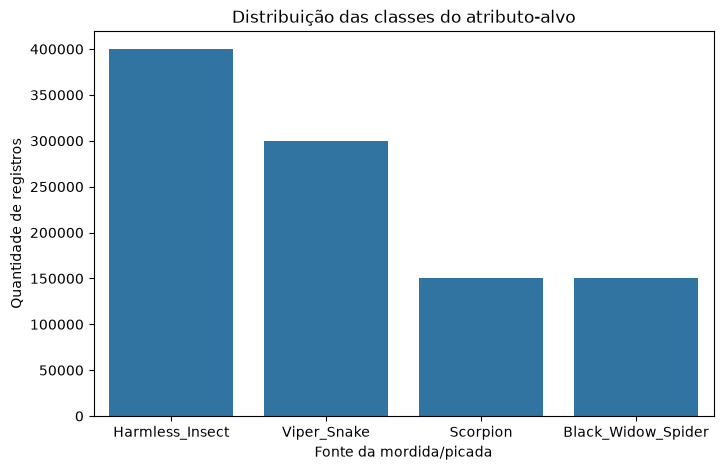

In [ ]:
print("Distribuição das classes (contagem):")
print(df['Bite_Source_Target'].value_counts())

print("\nDistribuição das classes (proporção):")
print(df['Bite_Source_Target'].value_counts(normalize=True).round(3))

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Bite_Source_Target', order=df['Bite_Source_Target'].value_counts().index)
plt.title('Distribuição das classes do atributo-alvo')
plt.xlabel('Fonte da mordida/picada')
plt.ylabel('Quantidade de registros')
plt.show()

O atributo-alvo apresenta desbalanceamento entre as classes: `Harmless_Insect` (40%) e `Viper_Snake` (30%) são majoritárias, enquanto `Scorpion` e `Black_Widow_Spider` (15% cada) são minoritárias. Esse desbalanceamento corresponde ao padrão de desbalanceamento esperado no mundo real, mas ele precisa ser considerado nas próximas etapas: será usada estratificação na separação treino/teste, e a avaliação dos modelos não deve se basear apenas em acurácia, mas também em métricas como precisão, revocação e F1-score por classe.

### 3.5 Distribuição das variáveis preditoras numéricas

,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic
count,1000000.00,1000000.00,1000000.00,1000000.00
mean,44.47,124.38,105.01,117.28
std,23.10,66.37,27.06,24.50
min,5.00,10.00,40.00,35.00
25%,24.00,67.00,82.00,99.00
50%,44.00,124.00,102.00,118.00
75%,64.00,182.00,124.00,133.00
max,84.00,239.00,243.00,223.00


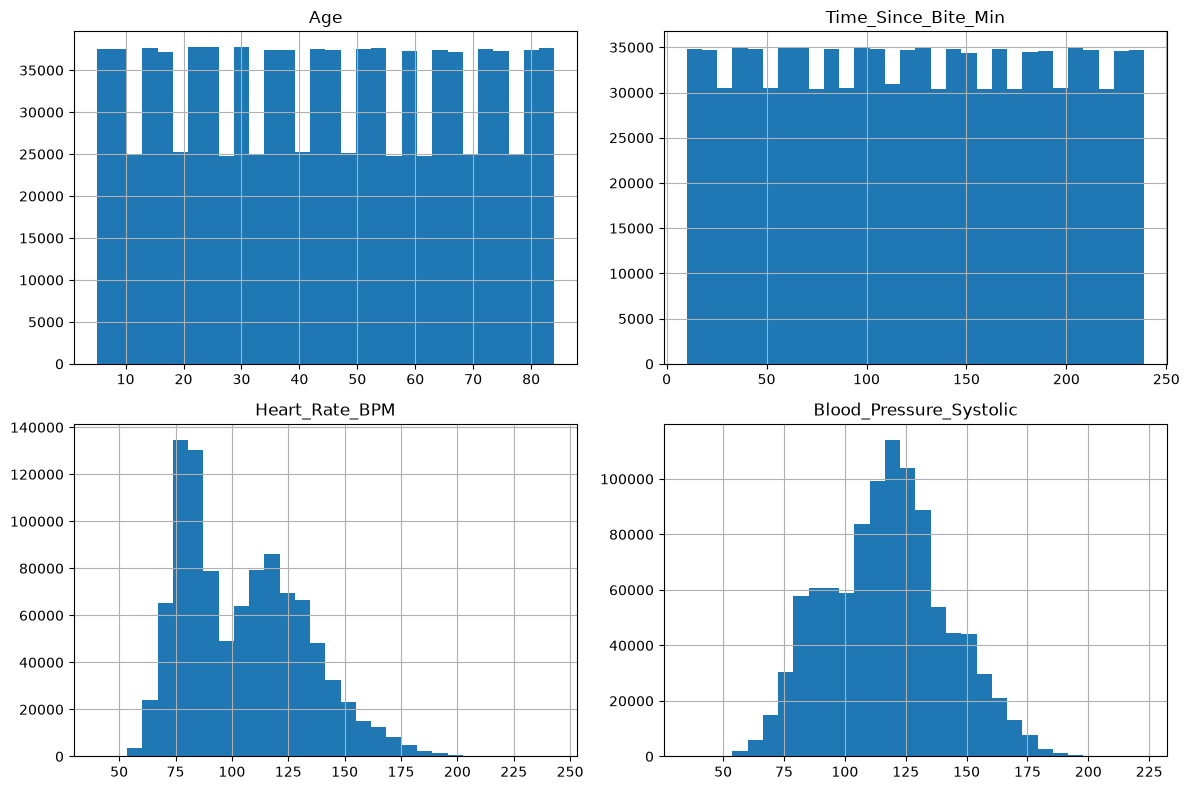

In [ ]:
colunas_numericas_originais = ['Age', 'Time_Since_Bite_Min', 'Heart_Rate_BPM', 'Blood_Pressure_Systolic']

display(df[colunas_numericas_originais].describe().round(2))

df[colunas_numericas_originais].hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

A idade dos pacientes varia entre valores compatíveis com a realidade (crianças a idosos), sem indícios de valores absurdos. O tempo desde a mordida (`Time_Since_Bite_Min`) apresenta ampla variação, o que é esperado dado que o atendimento pode ocorrer minutos ou horas após o incidente. A frequência cardíaca e a pressão sistólica apresentam distribuições consistentes com quadros de emergência médica, com alguns valores mais extremos que serão analisados na seção de outliers.

### 3.6 Distribuição das variáveis preditoras categóricas

In [ ]:
print("Distribuição de Gender:")
print(df['Gender'].value_counts(normalize=True).round(3))

print("\nDistribuição de Local_Swelling:")
print(df['Local_Swelling'].value_counts(normalize=True).round(3))

print("\nDistribuição de Muscle_Paralysis_Present:")
print(df['Muscle_Paralysis_Present'].value_counts(normalize=True).round(3))

print("\nDistribuição de Blood_Coagulation_Failure:")
print(df['Blood_Coagulation_Failure'].value_counts(normalize=True).round(3))

Distribuição de Gender:
Gender
Male      0.49
Female    0.49
Other     0.02
Name: proportion, dtype: float64

Distribuição de Local_Swelling:
Local_Swelling
Mild      0.550
Severe    0.273
None      0.150
Medium    0.027
Name: proportion, dtype: float64

Distribuição de Muscle_Paralysis_Present:
Muscle_Paralysis_Present
0    0.857
1    0.143
Name: proportion, dtype: float64

Distribuição de Blood_Coagulation_Failure:
Blood_Coagulation_Failure
0    0.747
1    0.253
Name: proportion, dtype: float64


O dataset aprsenta um bom balanceamento de genero (`Gender`), os dados ligados ao `local_Swelling`, `Muscle_Paralysis_Present` e `Blood_Coagulation_Failure` apresentam um maior desbalanceamento, porém, essas distribuições estão dentro do esperado, uma vez que a maioria das mordidas\picadas tendem a gerar algum tipo de reação, mesmo que leve - o que é registrado pelo `local_Swelling` - e apenas uma menor taxa das mordidas\picadas gera efeitos de paralisia muscular ou falhas de coagulação que estão associados à toxinas mais severas - o que afeta o balanceamento dos atributos: `Muscle_Paralysis_Present` e `Blood_Coagulation_Failure`-.

### 3.7 Checagem de consistência de domínio

In [ ]:
print("Idade mínima e máxima:", df['Age'].min(), "-", df['Age'].max())
print("Heart_Rate_BPM mínimo e máximo:", df['Heart_Rate_BPM'].min(), "-", df['Heart_Rate_BPM'].max())
print("Blood_Pressure_Systolic mínimo e máximo:", df['Blood_Pressure_Systolic'].min(), "-", df['Blood_Pressure_Systolic'].max())
print("Time_Since_Bite_Min mínimo e máximo:", df['Time_Since_Bite_Min'].min(), "-", df['Time_Since_Bite_Min'].max())

# Verifica valores fisiologicamente impossíveis (negativos ou zero onde não faz sentido)
inconsistencias_dominio = df[(df['Age'] <= 0) | (df['Heart_Rate_BPM'] <= 0) | (df['Blood_Pressure_Systolic'] <= 0)]
print(f"\nRegistros com valores fisiologicamente inválidos: {len(inconsistencias_dominio)}")

Idade mínima e máxima: 5 - 84
Heart_Rate_BPM mínimo e máximo: 40 - 243
Blood_Pressure_Systolic mínimo e máximo: 35 - 223
Time_Since_Bite_Min mínimo e máximo: 10 - 239

Registros com valores fisiologicamente inválidos: 0


O dataset não apresenta nenhum dado fisiologicamente impossivel, como valores negativos. Porém, apesar de conter dados esperados nos atributos de idade (`Age`) e tempo desde a mordida (`Time_Since_Bite_Min`), os valores de batimento cardiaco (`Heart_Rate_BPM`) e pressão sanguinea (`Blood_Pressure_Systolic`) apresentam valores mais extremos que podem indicar erros de medição ou quadro medicos severos, tais valores deverão ser analisados na seção de *outliers*

# 4.0 Analise exploratoria dos dados

### 4.1 Correlação entre variáveis numéricas

,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic
Age,1.000,0.002,-0.001,0.001
Time_Since_Bite_Min,0.002,1.000,0.000,-0.000
Heart_Rate_BPM,-0.001,0.000,1.000,0.207
Blood_Pressure_Systolic,0.001,-0.000,0.207,1.000


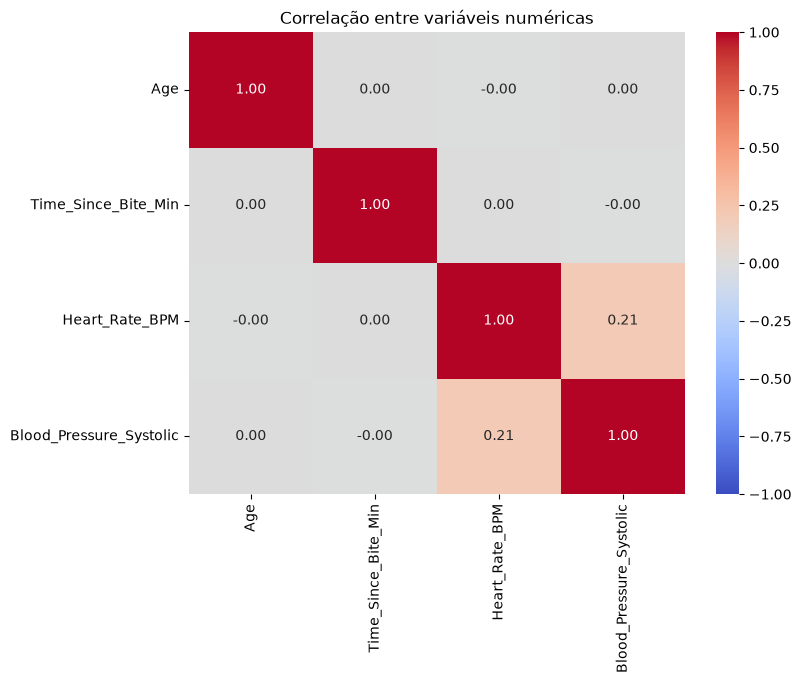

In [ ]:
# Matriz de correlação entre as variáveis numéricas originais
matriz_correlacao = df[colunas_numericas_originais].corr()

display(matriz_correlacao.round(3))

plt.figure(figsize=(8,6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlação entre variáveis numéricas')
plt.show()

As variaveis não apresentam uma grande correlação entre si, isso indica que cada variavel traz informações sem sofrer com redundancia de informações

### 4.2 Relação entre variáveis numéricas e o atributo-alvo

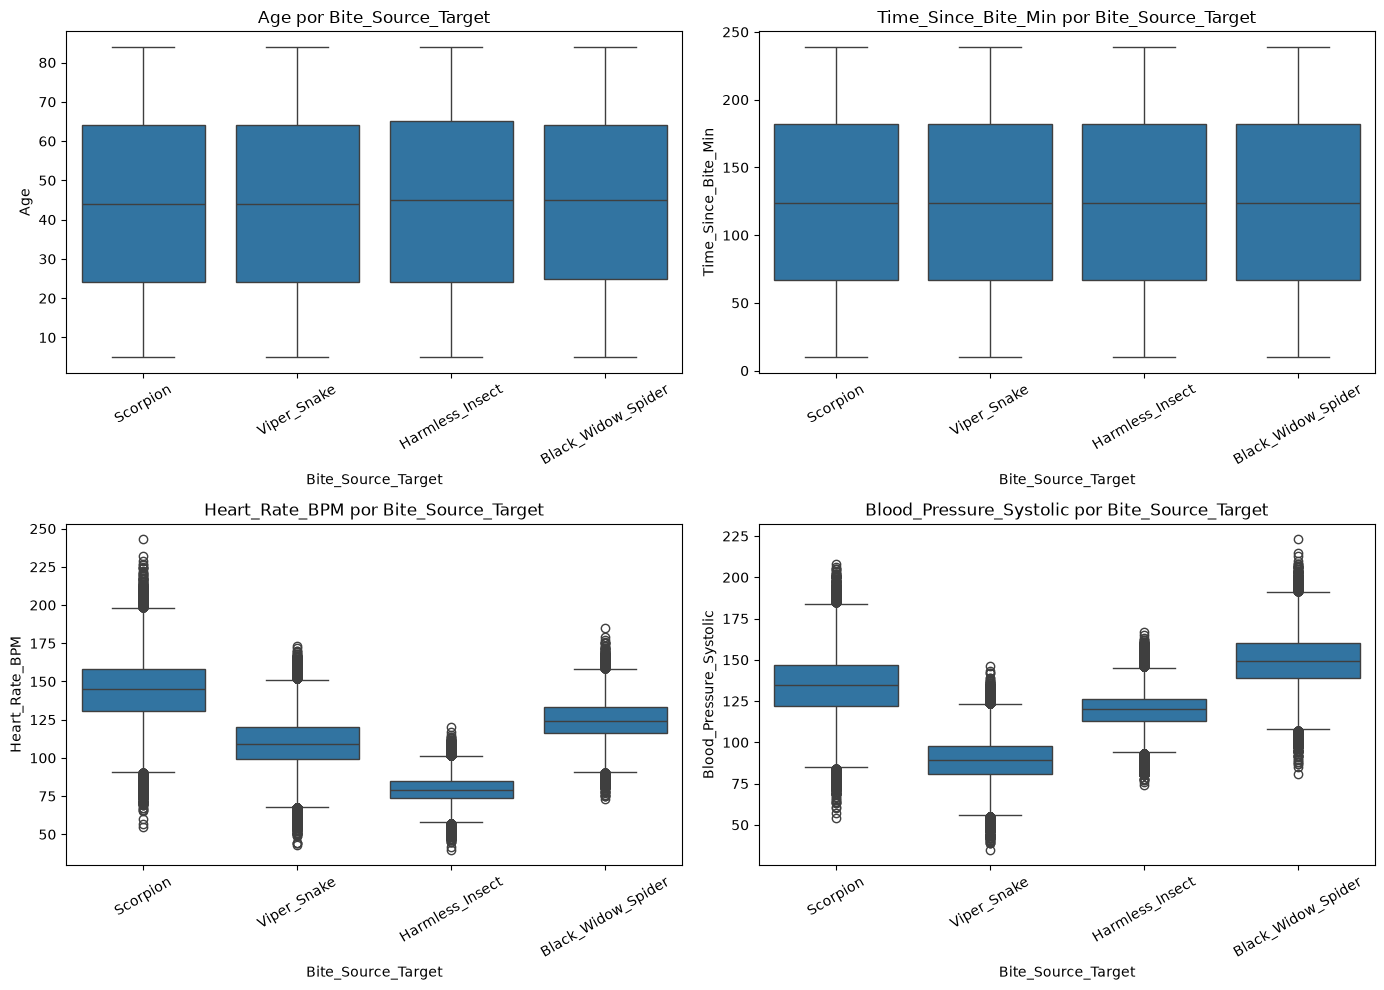

In [ ]:
# Boxplot de cada variável numérica separada por classe do atributo-alvo
fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for i, coluna in enumerate(colunas_numericas_originais):
    sns.boxplot(data=df, x='Bite_Source_Target', y=coluna, ax=axes[i])
    axes[i].set_title(f'{coluna} por Bite_Source_Target')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Os graficos acima indicam uma distribuição equilibrada entre as classes com relação aos atributos `Age` e `Time_Since_Bite_Min`, o que já era esperado, uma vez que esses valores não possuem relação direta com a fonte da mordida.

Por outro lado, as variaveis `Heart_Rate_BPM` e `Blood_Pressure_Systolic` Apresentam uma distribuição de valores mais distinguivel entre as 4 classes, o que indica uma maior relação entre essas variaveis e a classificação da mordida/picada

### 4.3 Relação entre variáveis categóricas/binárias e o atributo-alvo

In [ ]:
# Tabelas de frequência relativa de cada variável categórica/binária por classe do alvo
colunas_categoricas = ['Gender', 'Local_Swelling', 'Muscle_Paralysis_Present', 'Blood_Coagulation_Failure']

for coluna in colunas_categoricas:
    print(f"Tabela de frequência: {coluna} x Bite_Source_Target")
    display(pd.crosstab(df[coluna], df['Bite_Source_Target'], normalize='index').round(3))
    print('\n')

Tabela de frequência: Gender x Bite_Source_Target


Bite_Source_Target,Black_Widow_Spider,Harmless_Insect,Scorpion,Viper_Snake
Gender,,,,
Female,0.150,0.399,0.150,0.300
Male,0.150,0.400,0.151,0.300
Other,0.154,0.404,0.146,0.297




Tabela de frequência: Local_Swelling x Bite_Source_Target


Bite_Source_Target,Black_Widow_Spider,Harmless_Insect,Scorpion,Viper_Snake
Local_Swelling,,,,
Medium,0.0,0.000,0.000,1.0
Mild,0.0,0.727,0.273,0.0
None,1.0,0.000,0.000,0.0
Severe,0.0,0.000,0.000,1.0




Tabela de frequência: Muscle_Paralysis_Present x Bite_Source_Target


Bite_Source_Target,Black_Widow_Spider,Harmless_Insect,Scorpion,Viper_Snake
Muscle_Paralysis_Present,,,,
0,0.008,0.466,0.175,0.35
1,1.000,0.000,0.000,0.00




Tabela de frequência: Blood_Coagulation_Failure x Bite_Source_Target


Bite_Source_Target,Black_Widow_Spider,Harmless_Insect,Scorpion,Viper_Snake
Blood_Coagulation_Failure,,,,
0,0.201,0.535,0.201,0.063
1,0.000,0.000,0.000,1.000


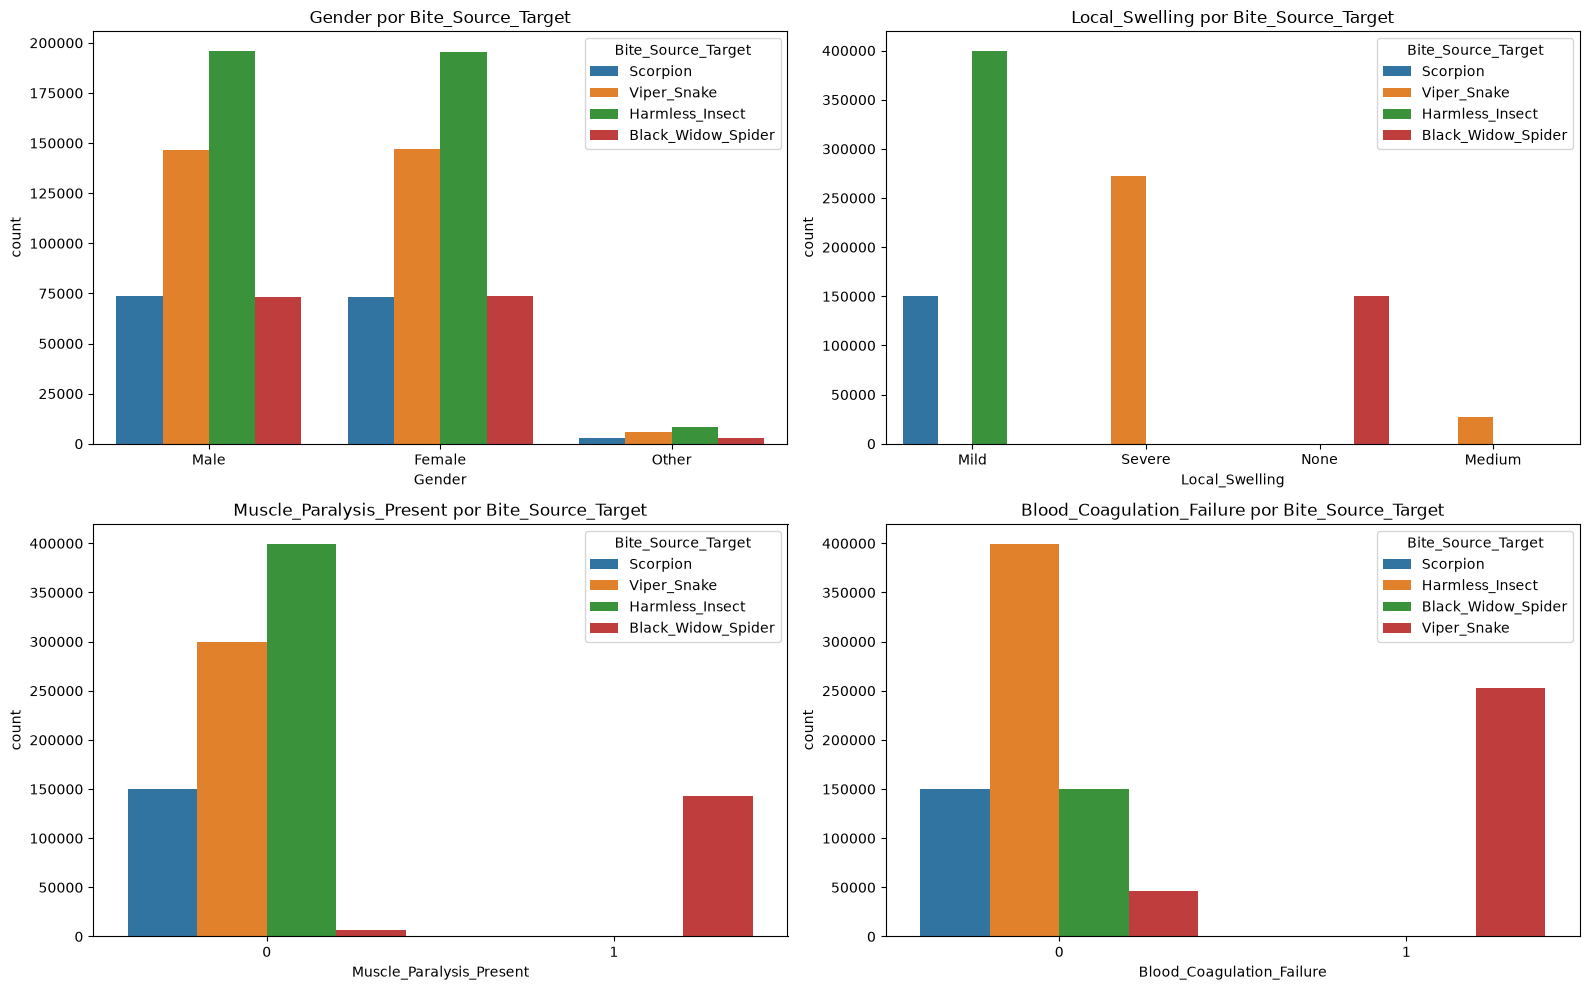

In [ ]:
# Gráficos de contagem de cada variável categórica/binária separados por classe do alvo
fig, axes = plt.subplots(2, 2, figsize=(16,10))
axes = axes.flatten()

for i, coluna in enumerate(colunas_categoricas):
    sns.countplot(data=df, x=coluna, hue='Bite_Source_Target', ax=axes[i])
    axes[i].set_title(f'{coluna} por Bite_Source_Target')

plt.tight_layout()
plt.show()

Enquanto as variaveis de genero (`Gender`) apresentam uma distribuição igualitaria entre todas as 4 classes, é possivel observar uma relação mais direta entre as outras variaveis e certas classes:

- `local_swelling`: a presença de reações leves (*Mild*) está ligada à picadas de insetos ou escorpiões, a ausencia de reações (*None*) está ligada à picadas de aranhas viúvas-negra, e a forte presença de reações (*medium* ou *severe*) está ligada à picadas de sepertes;

- `Muscle_Paralysis_Present`: A presença de paralizia muscular tem relação direta com picadas de aranhas vivúvas-negra;

- `Blood_Coagulation_Failure`: A presença de falha na coagulação do sangue é um indicativo direto de picadas de serpentes viboras.

### 4.4 Medidas de localidade e dispersão por grupo

In [ ]:
# Estatísticas descritivas das variáveis numéricas, separadas por classe do atributo-alvo
display(df.groupby('Bite_Source_Target')[colunas_numericas_originais[:2]].describe().round(2))
display(df.groupby('Bite_Source_Target')[colunas_numericas_originais[2:]].describe().round(2))

Age                                             \
                       count   mean    std  min   25%   50%   75%   max   
Bite_Source_Target                                                        
Black_Widow_Spider  150157.0  44.51  23.09  5.0  25.0  45.0  64.0  84.0   
Harmless_Insect     399623.0  44.53  23.09  5.0  24.0  45.0  65.0  84.0   
Scorpion            150292.0  44.43  23.06  5.0  24.0  44.0  64.0  84.0   
Viper_Snake         299928.0  44.39  23.12  5.0  24.0  44.0  64.0  84.0   

                   Time_Since_Bite_Min                                    \
                                 count    mean    std   min   25%    50%   
Bite_Source_Target                                                         
Black_Widow_Spider            150157.0  124.44  66.31  10.0  67.0  124.0   
Harmless_Insect               399623.0  124.26  66.40  10.0  67.0  124.0   
Scorpion                      150292.0  124.35  66.37  10.0  67.0  124.0   
Viper_Snake                   299928.0  124.53  66.38  10.0  67.0  124.0   

                                  
                      75%    max  
Bite_Source_Target                
Black_Widow_Spider  182.0  239.0  
Harmless_Insect     182.0  239.0  
Scorpion            182.0  239.0  
Viper_Snake         182.0  239.0

Heart_Rate_BPM                                            \
                            count    mean    std   min    25%    50%    75%   
Bite_Source_Target                                                            
Black_Widow_Spider       150157.0  124.50  11.99  73.0  116.0  124.0  133.0   
Harmless_Insect          399623.0   79.49   8.00  40.0   74.0   79.0   85.0   
Scorpion                 150292.0  144.50  19.99  55.0  131.0  145.0  158.0   
Viper_Snake              299928.0  109.45  15.00  43.0   99.0  109.0  120.0   

                          Blood_Pressure_Systolic                              \
                      max                   count    mean    std   min    25%   
Bite_Source_Target                                                              
Black_Widow_Spider  185.0                150157.0  149.53  14.97  81.0  139.0   
Harmless_Insect     120.0                399623.0  119.51  10.00  74.0  113.0   
Scorpion            243.0                150292.0  134.60  18.00  54.0  122.0   
Viper_Snake         173.0                299928.0   89.49  11.99  35.0   81.0   

                                         
                      50%    75%    max  
Bite_Source_Target                       
Black_Widow_Spider  149.0  160.0  223.0  
Harmless_Insect     120.0  126.0  167.0  
Scorpion            135.0  147.0  208.0  
Viper_Snake          89.0   98.0  146.0

`Age` e `Time_Since_Bite_Min` não discriminam as classes: médias, desvios-padrão e quartis são praticamente idênticos entre os quatro tipos de picada. Isso é esperado — não há motivo biológico para a idade da vítima ou o tempo até o atendimento dependerem de qual animal causou a picada. Essas duas variáveis, portanto, tendem a ter baixo poder preditivo isoladamente.

As variaveis `Heart_Rate_BPM` e `Blood_Pressure_Systolic`, por outro lado, possuem uma relação mais direta com as classes:

`Heart_Rate_BPM`:
- `Harmless_Insect`: média 79,5 bpm (a mais baixa, e com o menor desvio-padrão, 8,0 — grupo mais homogêneo)

- `Viper_Snake`: média 109,5 bpm

- `Black_Widow_Spider`: média 124,5 bpm

- `Scorpion`: média 144,5 bpm (a mais alta, com maior desvio-padrão, 20,0 — grupo mais heterogêneo)

`Blood_Pressure_Systolic`:

- `Black_Widow_Spider`: média 149,53 (a mais alta, indicando hipertensão)

- `Harmless_Insect`: média 119,51 (dentro da faixa normal)

- `Scorpion`: média 134,60

- `Viper_Snake`: média 89,49 (a mais baixa, indicando hipotensão)

A analise conjunta dessas variaveis parece auxiliar no processo de classificação, pois cada uma apresenta um comportamento distinto em relação a cada classe, por exemplo, enquanto `Viper_Snake` provoca uma pressão seguinea baixa, os batimentos cardiacos se mantem em um valor relativamente alto, já no caso da `Black_Widow_Spider`, tanto a pressão seguinea quanto os batimentos cardiacos apresentam um aumento.

### 4.5 Dispersão entre pares de variáveis numéricas por classe

Como o dataset possui aproximadamente 1 milhão de registros, um gráfico de dispersão com todos os pontos ficaria poluído e lento para renderizar. Por isso, para esta visualização especificamente, foi utilizada uma amostra aleatória dos dados apenas para fins de representação gráfica — os dados completos continuam sendo utilizados em todas as demais análises e no treinamento dos modelos.

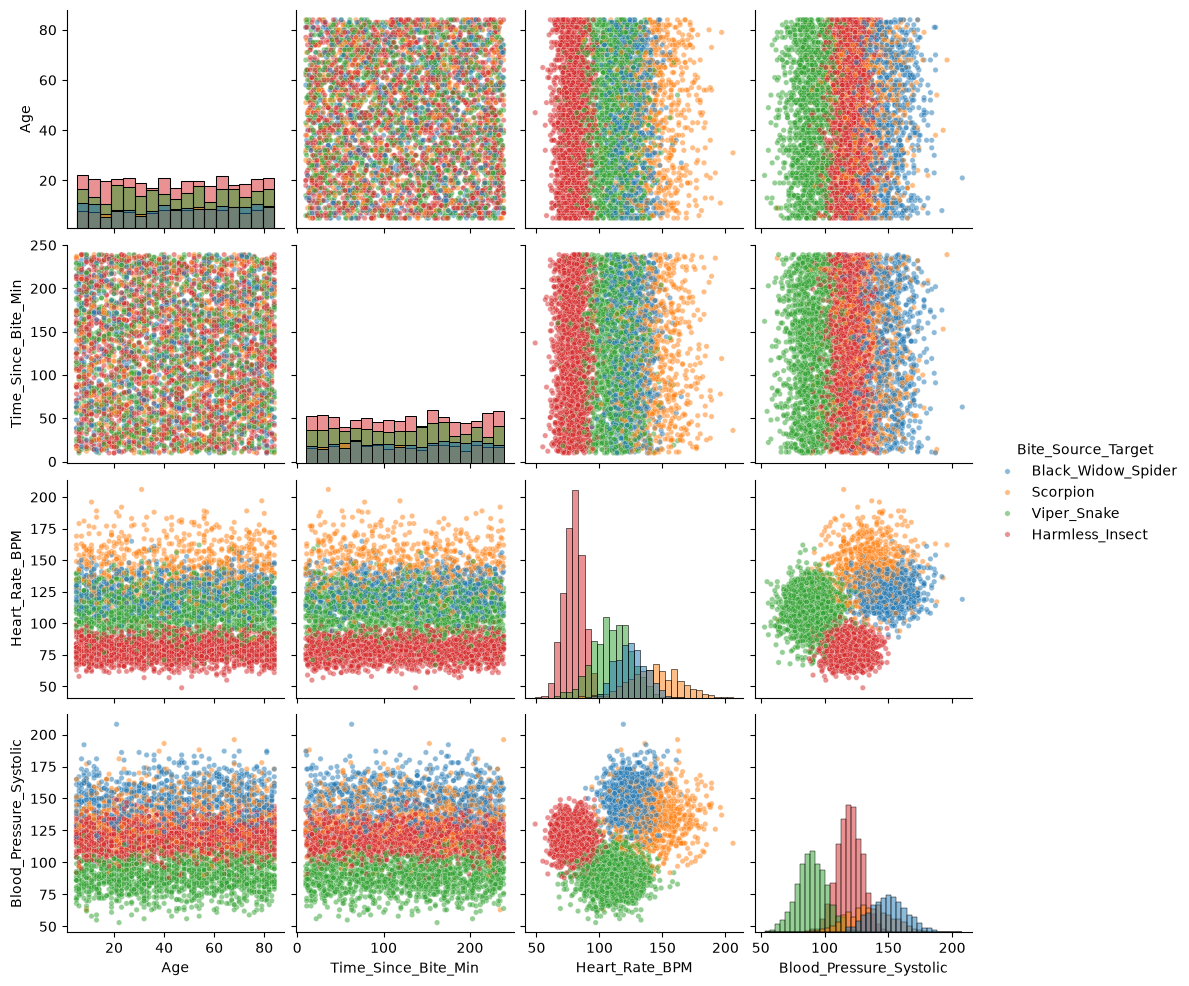

In [ ]:
# Amostra aleatória apenas para visualização (o dataset completo continua sendo usado nas demais etapas)
df_amostra_visualizacao = df.sample(n=5000, random_state=42)

sns.pairplot(
    df_amostra_visualizacao,
    vars=colunas_numericas_originais,
    hue='Bite_Source_Target',
    diag_kind='hist',
    plot_kws={'alpha': 0.5, 's': 15}
)
plt.show()

A visualização por pares confirma, de forma agregada, os padrões já identificados nas seções anteriores. As combinações envolvendo `Age` e `Time_Since_Bite_Min` não apresentam nenhuma separação entre as classes — os pontos aparecem completamente sobrepostos em todos os painéis onde essas variáveis participam, reforçando que ambas têm baixo poder discriminativo para o problema.

A combinação `Heart_Rate_BPM` × `Blood_Pressure_Systolic` volta a se destacar como a mais informativa, formando agrupamentos por classe visivelmente distintos — já discutido em detalhe na seção 4.4. Vale reforçar aqui apenas que essa separação se mantém consistente mesmo numa amostra menor dos dados, o que indica que o padrão é estável e não um artefato de algum subconjunto específico.

Os demais painéis cruzando `Heart_Rate_BPM` ou `Blood_Pressure_Systolic` com `Age`/`Time_Since_Bite_Min` não mostram estrutura adicional além da já observada isoladamente: as classes se distribuem em faixas horizontais/verticais bem definidas no eixo da variável fisiológica, mas sem nenhuma tendência ao longo do eixo demográfico/temporal. Isso confirma que o poder de separação do dataset está concentrado nas variáveis fisiológicas (`Heart_Rate_BPM`, `Blood_Pressure_Systolic`) e nas binárias (`Muscle_Paralysis_Present`, `Blood_Coagulation_Failure`), enquanto `Age` e `Time_Since_Bite_Min` funcionam essencialmente como ruído para a tarefa de classificação.


# 5.0 Pre-processamento e separação dos dados

### 5.1 Limpeza de dados irrelevantes

A coluna `Patient_ID` não possui valor preditivo, logo a sua presença é dispensavel

In [ ]:
df_Processamento = df.copy()

# Remove a coluna Patient_ID pois não tem valor preditivo
if 'Patient_ID' in df_Processamento.columns:
    df_Processamento = df_Processamento.drop('Patient_ID', axis=1)

display(df_Processamento.head())

,Age,Gender,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Local_Swelling,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Bite_Source_Target
0,56,Male,153,126,121,Mild,0,0,Scorpion
1,19,Female,124,150,138,Mild,0,0,Scorpion
2,76,Male,196,99,100,Severe,0,1,Viper_Snake
3,65,Male,143,139,144,Mild,0,0,Scorpion
4,25,Female,195,87,98,Mild,0,0,Harmless_Insect


### 5.2 Valores nulos

In [ ]:
# Verificando se há valores nulos
print("\nVerificando valores nulos:")
print(df_Processamento.isnull().sum())


Verificando valores nulos:
Age                          0
Gender                       0
Time_Since_Bite_Min          0
Heart_Rate_BPM               0
Blood_Pressure_Systolic      0
Local_Swelling               0
Muscle_Paralysis_Present     0
Blood_Coagulation_Failure    0
Bite_Source_Target           0
dtype: int64


Assim como verificado na etapa de compreensão dos dados, o dataset não apresenta valores nulos

### 5.3 Valores duplicados ou inconsistentes

Verifica a existencia de valores duplicados desconsiderando a coluna de classificação `Bite_Source_Target`, o que inclui tanto entradas duplicadas (mesma classificação) e inconsistentes (classificações diferentes)

In [ ]:
# Busca valores duplicados com base nas colunas 'Age','Gender','Time_Since_Bite_Min','Heart_Rate_BPM','Blood_Pressure_Systolic','Local_Swelling','Muscle_Paralysis_Present','Blood_Coagulation_Failure'
df_duplicates = df_Processamento[ df_Processamento.duplicated(subset=['Age','Gender','Time_Since_Bite_Min','Heart_Rate_BPM','Blood_Pressure_Systolic','Local_Swelling','Muscle_Paralysis_Present','Blood_Coagulation_Failure'],keep=False)]

# Caso existam valores duplicados, exibe
if len(df_duplicates)>0:
    print(f"\n Numero de amostras duplicadas: {len(df_duplicates)}")
    print('\n Exemplos de amostras duplicadas:')
    display(df_duplicates)
else:
    print('Não existem valores duplicados')


 Numero de amostras duplicadas: 5639

 Exemplos de amostras duplicadas:


,Age,Gender,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Local_Swelling,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Bite_Source_Target
506,43,Male,62,83,109,Mild,0,0,Harmless_Insect
751,65,Female,190,74,120,Mild,0,0,Harmless_Insect
975,10,Male,91,81,123,Mild,0,0,Harmless_Insect
1220,48,Male,139,87,124,Mild,0,0,Harmless_Insect
1493,50,Female,25,147,135,Mild,0,0,Scorpion
...,...,...,...,...,...,...,...,...,...
999039,30,Male,177,131,120,Mild,0,0,Scorpion
999255,38,Male,117,85,119,Mild,0,0,Harmless_Insect
999395,60,Male,34,88,116,Mild,0,0,Harmless_Insect
999615,67,Female,24,78,129,Mild,0,0,Harmless_Insect


Como existem entradas duplicadas, é necessario realizar um tratamento a fim de evitar problemas de enviesamento ou inconsistencias do modelo. Primeiro devemos diferenciar as entradas redundantes (mesma classficação) das entradas inconsistentes (classificações distintas).

Fazendo uma nova busca por entradas duplicadas levando em consideração a coluna do atributo alvo `Bite_source_target` ou utilizando a função `drop_duplicates` é possivel encontrar e remover apenas os valores redundantes, nesse caso, foi escolhido remover os valores repetidos mantendo uma unica entrada de cada repetição.

In [ ]:
# Remove os valores duplicados deixando apenas a primeira ocorrencia
df_Processamento = df_Processamento.drop_duplicates(keep = 'first')


# Novo teste de valores duplicados
# Captura valores inconsistentes (entradas duplicadas com classificações diferentes)
df_duplicates = df_Processamento[ df_Processamento.duplicated(subset=['Age','Gender','Time_Since_Bite_Min','Heart_Rate_BPM','Blood_Pressure_Systolic','Local_Swelling','Muscle_Paralysis_Present','Blood_Coagulation_Failure'],keep=False)]

# Caso existam valores inconsistentes, exibe
if len(df_duplicates)>0:
    print(f'\nAmostras inconsistentes:{df_duplicates.shape[0]}')
    print('\nExemplos de amostras inconsistentes:')
    display(df_duplicates)
else:
    print('Não existem valores inconsistentes')


Amostras inconsistentes:8

Exemplos de amostras inconsistentes:


,Age,Gender,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Local_Swelling,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Bite_Source_Target
209228,6,Female,12,80,110,Mild,0,0,Scorpion
219397,28,Female,62,82,132,Mild,0,0,Harmless_Insect
220381,6,Female,12,80,110,Mild,0,0,Harmless_Insect
487733,28,Female,136,96,117,Mild,0,0,Scorpion
505569,28,Female,136,96,117,Mild,0,0,Harmless_Insect
527697,14,Female,222,90,108,Mild,0,0,Scorpion
686822,14,Female,222,90,108,Mild,0,0,Harmless_Insect
875419,28,Female,62,82,132,Mild,0,0,Scorpion


A nova verificação de valores duplicados revelou a existencia de entradas inconsistentes, ou seja, entradas duplicadas que possuem uma classificação distinta, essas entradas geram problemas de incosistencia do modelo e geralmente estão ligadas à casos especiais ou erros de medição. Como nenhum dos dados inconsistentes é confiavel, o tratamento adotado foi remover todas as entradas inconsistentes.

Remove todos os valores inconsistentes e realiza um novo teste de duplicatas apenas para garantir que os dados foram totalmente tratados

In [ ]:
# Remove todos os valores inconsistentes
df_Processamento = df_Processamento.drop_duplicates(subset=['Age','Gender','Time_Since_Bite_Min','Heart_Rate_BPM','Blood_Pressure_Systolic','Local_Swelling','Muscle_Paralysis_Present','Blood_Coagulation_Failure'], keep = False)

# Ultimo teste de valores duplicados\inconsistentes
df_duplicates = df_Processamento[ df_Processamento.duplicated(subset=['Age','Gender','Time_Since_Bite_Min','Heart_Rate_BPM','Blood_Pressure_Systolic','Local_Swelling','Muscle_Paralysis_Present','Blood_Coagulation_Failure'],keep=False)]

# Caso existam valores inconsistentes, exibe
if len(df_duplicates)>0:
    print('\nAmostras inconsistentes:')
    display(df_duplicates)
else:
    print('Não existem valores inconsistentes ou duplicados')

Não existem valores inconsistentes ou duplicados


### 5.4 Dados não numericos

Dados não numericos afetam a eficiencia do processo de treinamento do modelo, além disso, a maioria dos modelos não conseguem lidar com dados não numericos. Assim como observado na etapa de compreensão dos dados, certas colunas do dataset possuem entradas não numericas que devem ser tratadas

In [ ]:
print(f"Quantidade de registros: {df_Processamento.shape[0]}")
print(f"Quantidade de atributos: {df_Processamento.shape[1]}")
print("\nTipos de dados por coluna:")
print(df_Processamento.dtypes)

Quantidade de registros: 997170
Quantidade de atributos: 9

Tipos de dados por coluna:
Age                          int64
Gender                         str
Time_Since_Bite_Min          int64
Heart_Rate_BPM               int64
Blood_Pressure_Systolic      int64
Local_Swelling                 str
Muscle_Paralysis_Present     int64
Blood_Coagulation_Failure    int64
Bite_Source_Target             str
dtype: object


As colunas `Local_Swelling`, `Gender` e `Bite_Source_Target` possuem valores do tipo `Object` que devem ser tratados a fim de facilitar o processamento dos dados. Nesse caso, as entradas `Local_Swelling` e `Gender` serão convertidas para entradas bollean, com a adição de colunas extras, enquanto a entrada `Bite_Source_Target` será convertida pera uma entrada numerica

In [ ]:
# 1. Variáveis Categóricas Preditoras
if 'Gender' in df_Processamento.columns and 'Local_Swelling' in df_Processamento.columns:
    df_Processamento = pd.get_dummies(df_Processamento, columns=['Gender', 'Local_Swelling'], drop_first=True)
elif 'Gender' in df_Processamento.columns:
    df_Processamento = pd.get_dummies(df_Processamento, columns=['Gender'], drop_first=True)
elif 'Local_Swelling' in df_Processamento.columns:
    df_Processamento = pd.get_dummies(df_Processamento, columns=['Local_Swelling'], drop_first=True)

# 2. Variável Alvo (Label Encoding)
le = LabelEncoder()
df_Processamento['Bite_Source_Target'] = le.fit_transform(df_Processamento['Bite_Source_Target'])

# Verificando como ficou o dataset após as transformações
display(df_Processamento.head())

,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Bite_Source_Target,Gender_Male,Gender_Other,Local_Swelling_Mild,Local_Swelling_None,Local_Swelling_Severe
0,56,153,126,121,0,0,2,True,False,True,False,False
1,19,124,150,138,0,0,2,False,False,True,False,False
2,76,196,99,100,0,1,3,True,False,False,False,True
3,65,143,139,144,0,0,2,True,False,True,False,False
4,25,195,87,98,0,0,1,False,False,True,False,False


### 5.5 Separação de dados de treino e teste (20/80)


Agora que o tratamento inicial dos dados já foi realizado (remoção de duplicatas e conversão dos valores não numericos), o dataset inicial será separado em dois grupos distintos usando uma proporção de 20% para testes e 80% para treinamento.

Essa seperação será feita levando em conta a distribuição orginal das classes, visando manter essa mesma distribuição em ambas partes.

In [ ]:
# Separando features (X) e target (y)
X = df_Processamento.drop('Bite_Source_Target', axis=1)
y = df_Processamento['Bite_Source_Target']

# Dividindo os dados em conjuntos de treino e teste (80/20) de forma estratificada
# A estratificação garante que a proporção de cada classe em 'y' seja a mesma nos conjuntos de treino e teste.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamanho do conjunto de treino (X_train): {X_train.shape}")
print(f"Tamanho do conjunto de teste (X_test): {X_test.shape}")
print(f"Tamanho do conjunto de treino (y_train): {y_train.shape}")
print(f"Tamanho do conjunto de teste (y_test): {y_test.shape}")

# Verificar a distribuição das classes nos conjuntos de treino e teste
print("\nDistribuição das classes em y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribuição das classes em y_test:")
print(y_test.value_counts(normalize=True))

Tamanho do conjunto de treino (X_train): (797736, 11)
Tamanho do conjunto de teste (X_test): (199434, 11)
Tamanho do conjunto de treino (y_train): (797736,)
Tamanho do conjunto de teste (y_test): (199434,)

Distribuição das classes em y_train:
Bite_Source_Target
1    0.398682
3    0.300231
2    0.150633
0    0.150455
Name: proportion, dtype: float64

Distribuição das classes em y_test:
Bite_Source_Target
1    0.398683
3    0.300230
2    0.150631
0    0.150456
Name: proportion, dtype: float64


### 5.6 Normalização

Modelos que utilizam algoritmos matematicos para realizar o processo de classificação, como o `K-Nearest Neighbors (KNN)` podem apresentar falhas serevas caso as colunas numericas aprsentem dimenções distintas, nesse caso as colunas com valores maiores acabam tendo um maior peso durante a classificação, a fim de evitar esse problema, foi realizada a normalização dos dados de treino e de testes

In [ ]:
# apresenta as principais estatísticas da base de dados de treinamento
df_detalhes = X_train.describe()

display(df_detalhes.round(8))

,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Muscle_Paralysis_Present,Blood_Coagulation_Failure
count,797736.000000,797736.000000,797736.000000,797736.000000,797736.000000,797736.000000
mean,44.461193,124.387816,105.049305,117.303164,0.143346,0.253490
std,23.085763,66.364376,27.062013,24.529121,0.350425,0.435009
min,5.000000,10.000000,42.000000,39.000000,0.000000,0.000000
25%,24.000000,67.000000,82.000000,99.000000,0.000000,0.000000
50%,44.000000,124.000000,102.000000,118.000000,0.000000,0.000000
75%,64.000000,182.000000,124.000000,133.000000,0.000000,1.000000
max,84.000000,239.000000,243.000000,223.000000,1.000000,1.000000


In [ ]:
# Inicializa o normalizador (Média 0 e Desvio Padrão 1)
scaler = StandardScaler()

# Lista das colunas numéricas que precisam de ajuste
colunas_numericas = ['Age', 'Time_Since_Bite_Min', 'Heart_Rate_BPM', 'Blood_Pressure_Systolic']

# Cria uma copia normalizada dos dados
X_train_Normalizado = X_train.copy()

# Normaliza as colunas numéricas
X_train_Normalizado[colunas_numericas] = scaler.fit_transform(X_train_Normalizado[colunas_numericas])

# Exibe os dados normalizados e as suas estatisticas
display(X_train_Normalizado.head())
print('\n')
display(X_train_Normalizado.describe().round(8))

,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Gender_Male,Gender_Other,Local_Swelling_Mild,Local_Swelling_None,Local_Swelling_Severe
393316,-0.106611,1.003735,0.441604,0.762231,0,0,True,False,True,False,False
852561,0.629774,-1.271584,-0.740866,-0.053127,0,0,True,False,True,False,False
611780,-1.059580,-0.216800,0.330748,-0.868485,0,1,False,False,False,False,True
191771,1.019625,1.139350,-0.925627,-0.256967,0,0,False,False,True,False,False
412650,-1.449431,1.169486,-1.184292,0.476855,0,0,True,False,True,False,False


,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Muscle_Paralysis_Present,Blood_Coagulation_Failure
count,797736.000000,797736.000000,797736.000000,797736.000000,797736.000000,797736.000000
mean,0.000000,-0.000000,0.000000,-0.000000,0.143346,0.253490
std,1.000001,1.000001,1.000001,1.000001,0.350425,0.435009
min,-1.709331,-1.723634,-2.329810,-3.192255,0.000000,0.000000
25%,-0.886313,-0.864739,-0.851722,-0.746181,0.000000,0.000000
50%,-0.019977,-0.005844,-0.112678,0.028409,0.000000,0.000000
75%,0.846358,0.868120,0.700270,0.639927,0.000000,1.000000
max,1.712693,1.727015,5.097580,4.309038,1.000000,1.000000


In [ ]:
# Cria uma copia normalizada dos dados de teste
X_test_Normalizado = X_test.copy()

# Aplica a normalização nas colunas numéricas do conjunto de teste
# IMPORTANTE: Usamos APENAS 'transform' com o scaler já ajustado em X_train
X_test_Normalizado[colunas_numericas] = scaler.transform(X_test_Normalizado[colunas_numericas])

# Exibe os dados normalizados e as suas estatísticas
print("X_test normalizado (primeiras 5 linhas):")
display(X_test_Normalizado.head())
print('\nEstatísticas descritivas de X_test normalizado:')
display(X_test_Normalizado.describe().round(8))

X_test normalizado (primeiras 5 linhas):


,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Gender_Male,Gender_Other,Local_Swelling_Mild,Local_Swelling_None,Local_Swelling_Severe
539800,0.759724,-1.663361,-1.221244,0.232248,0,0,False,False,True,False,False
155569,0.456507,0.822915,0.478557,1.536821,1,0,False,False,False,True,False
915850,-1.666015,-0.337347,0.293796,-0.623878,0,1,False,False,False,False,True
139817,1.279526,1.651673,-0.814770,-0.053127,0,0,True,False,True,False,False
857484,0.976308,-1.377062,1.771883,1.740660,0,0,False,False,True,False,False



Estatísticas descritivas de X_test normalizado:


,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Muscle_Paralysis_Present,Blood_Coagulation_Failure
count,199434.000000,199434.000000,199434.000000,199434.000000,199434.000000,199434.000000
mean,0.002105,-0.000279,0.000710,-0.002886,0.143286,0.253106
std,1.002363,1.000590,1.001158,0.998409,0.350365,0.434792
min,-1.709331,-1.723634,-2.403714,-3.355327,0.000000,0.000000
25%,-0.886313,-0.864739,-0.851722,-0.746181,0.000000,0.000000
50%,-0.019977,-0.005844,-0.112678,0.028409,0.000000,0.000000
75%,0.889675,0.868120,0.700270,0.639927,0.000000,1.000000
max,1.712693,1.727015,4.691106,3.656751,1.000000,1.000000


### 5.7 Analise de *outliers*

Utilizando uma representação grafica dos dados de treinamento é possivel analisar a distribuição numerica e analisar a presença de outliers



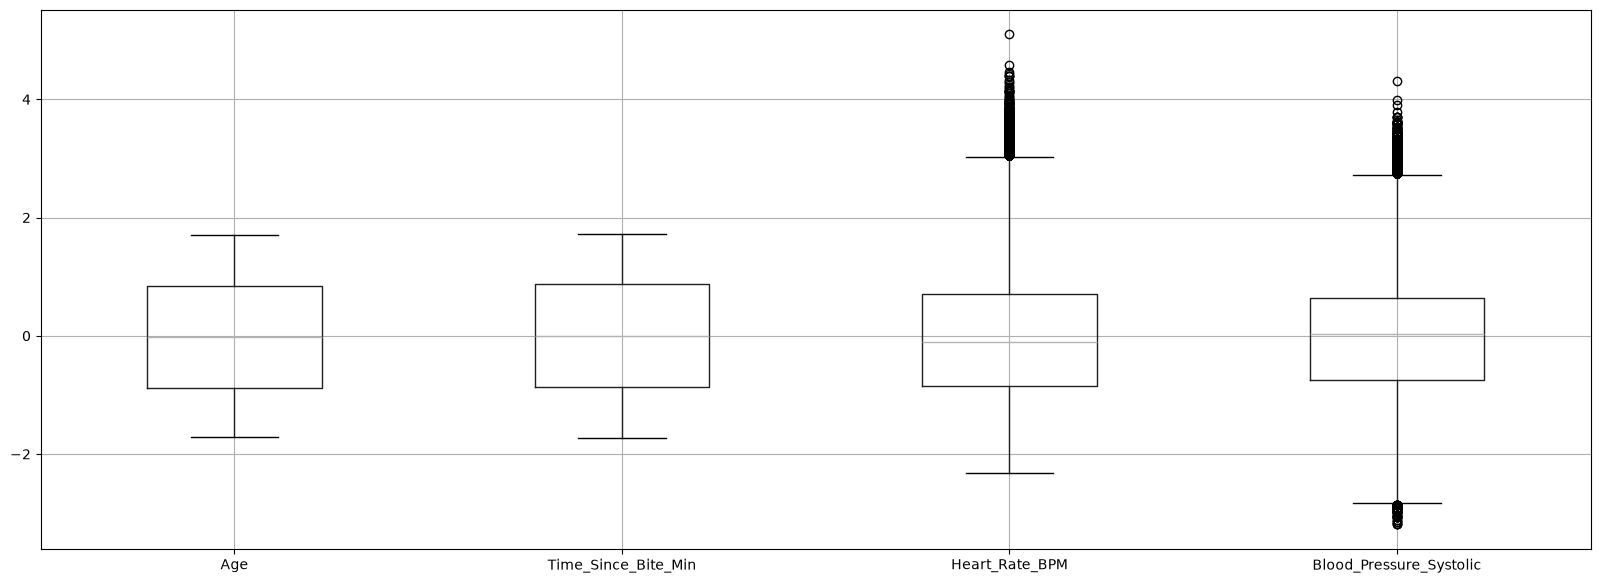

In [ ]:
X_train_Normalizado[colunas_numericas].boxplot(figsize=(20,7))
plt.show()

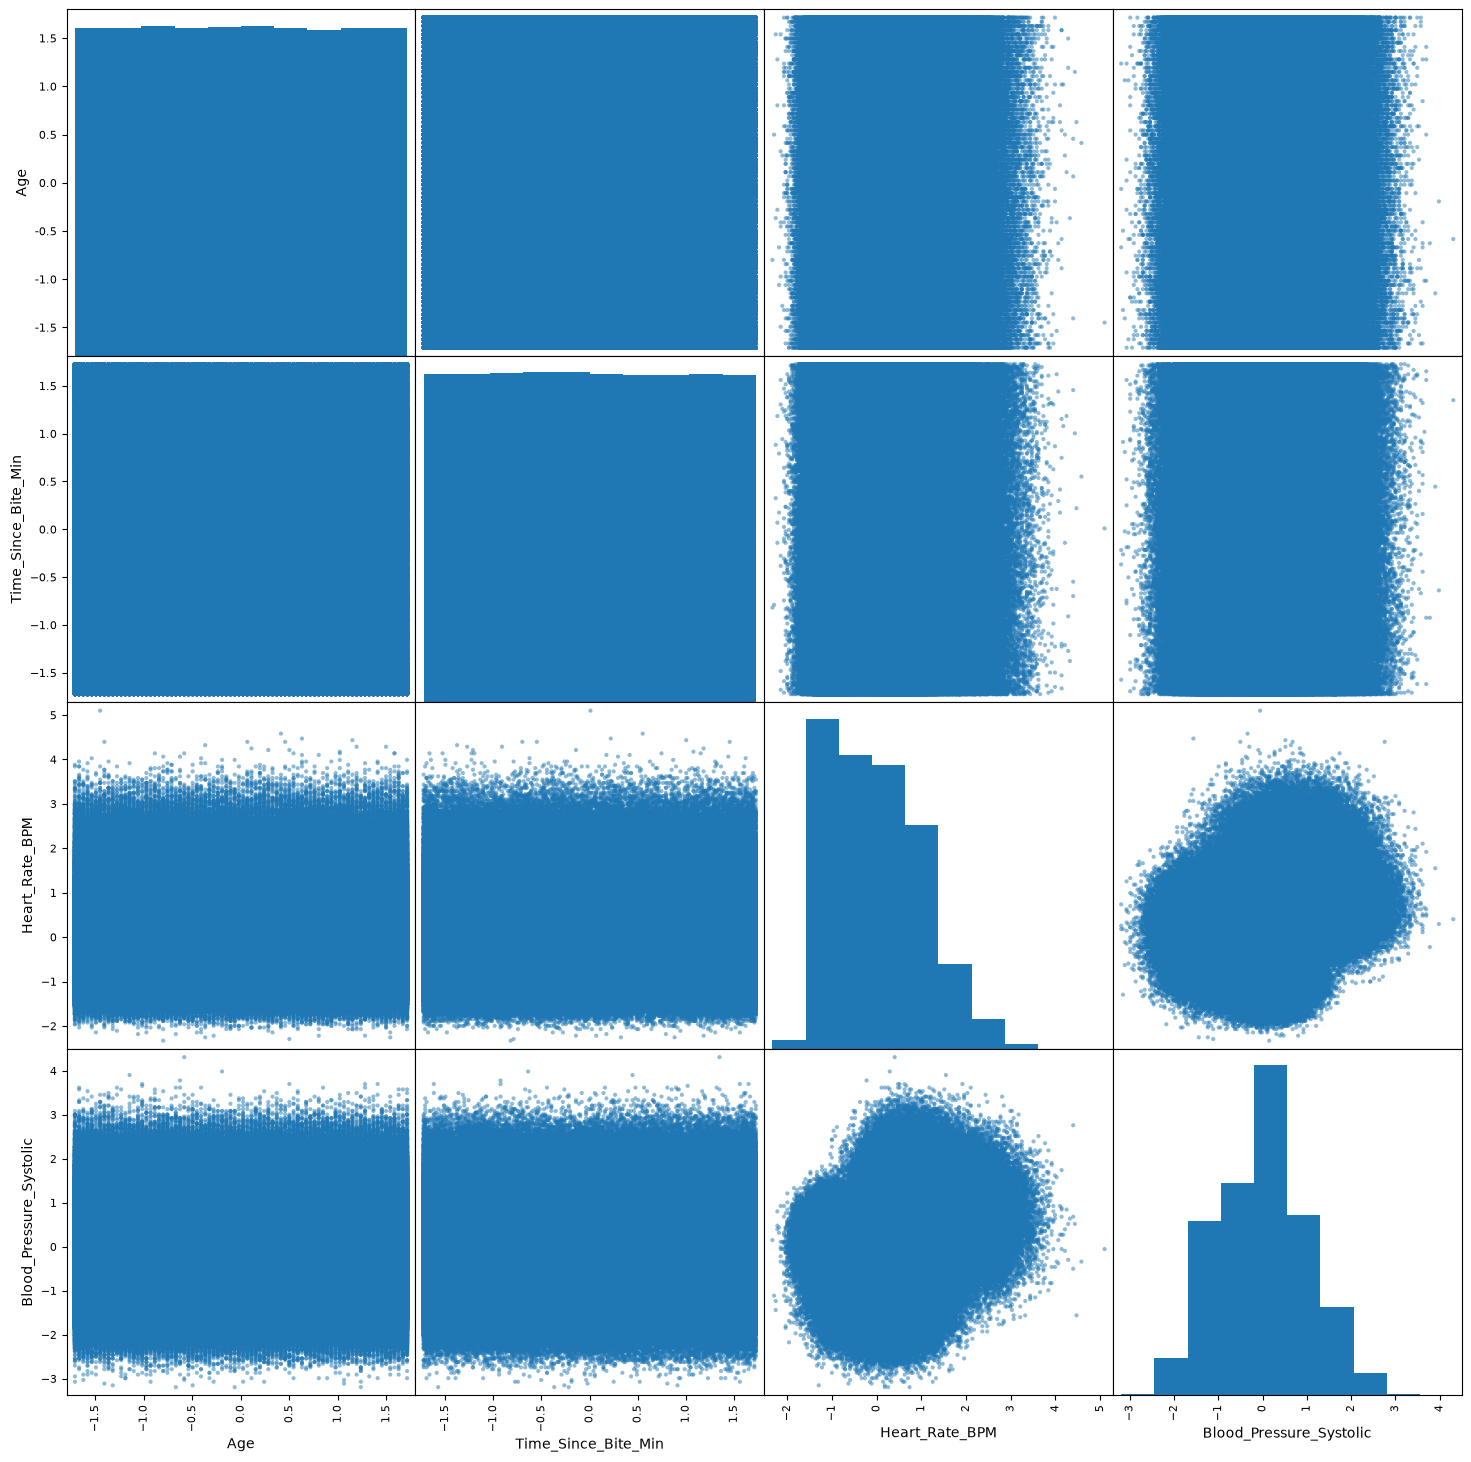

In [ ]:
pd.plotting.scatter_matrix(X_train_Normalizado[colunas_numericas], figsize=(18,18))

plt.show()

A analise grafica dos dados numericos revela a presença de outliers nas colunas `Heart_rate_bpm` e `Blood_presure_sistolic`. Porém, tais outliers não parecem ligados à erros de medição e representam dados importante para o diagnostico de estado geral do paceiente. Taxas elevadas de batimentos cardiacos podem indicar problemas cardiacos ligados à efeitos de neurotoxinas por exemplo, logo esses dados não devem ser removidos

# 6.0 Modelagem

### 6.1 Baseline

Para o baseline, utilizamos a estratégia 'Most Frequent', onde o modelo sempre chuta o diagnóstico mais frequente do dataset, sem olhar nenhum dado do paciente

Acurácia do baseline: 0.39868327366447043

                    precision    recall  f1-score   support

Black_Widow_Spider       0.00      0.00      0.00     30006
   Harmless_Insect       0.40      1.00      0.57     79511
          Scorpion       0.00      0.00      0.00     30041
       Viper_Snake       0.00      0.00      0.00     59876

          accuracy                           0.40    199434
         macro avg       0.10      0.25      0.14    199434
      weighted avg       0.16      0.40      0.23    199434



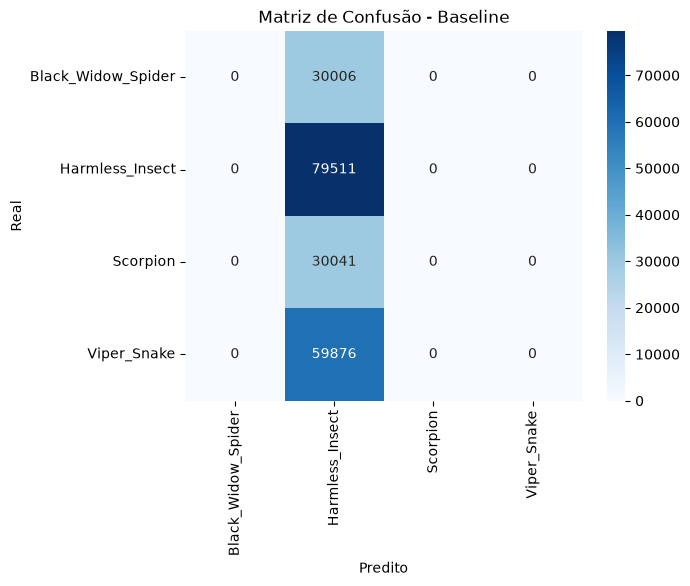

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Baseline usando estratégia most_frequent
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

print("Acurácia do baseline:", accuracy_score(y_test, y_pred_baseline))
print()

# Relatório por classe
# usa le.classes_ para mostrar os nomes originais em vez dos números 0, 1, 2, 3
print(classification_report(y_test, y_pred_baseline, target_names=le.classes_, zero_division=0))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_baseline)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Baseline')
plt.show()

No nosso caso, o diagnóstico mais frequente é o Harmless_Insect, com ~40%. Consequentemente, esse baseline tem uma acurácia de ~40%. Ele tem 100% de recall em Harmless_Insect, mas 0% em todo o resto, resultando em apenas 0,14% na pontuação F1-macro.

A matriz de confusão mostra que o modelo previu Harmless_Insect em todos os casos, acertou em todos os casos que era, e errou em todos os casos que não era.

### 6.2 Modelos Utilizados

Para os modelos candidatos, utilizaremos:
1. SGDClassifier:

- Descrição: Um modelo que soma cada característica do paciente multiplicada por um peso, e decide a classe com base nesse resultado. O treino ajusta esses pesos aos poucos, passando pelos dados repetidas vezes, o que permite lidar bem com o volume de dados deste dataset (~1 milhão de linhas).
- Parâmetros:
    - `loss='hinge'`: A função usada para medir o quão errado o modelo estava em cada previsão durante o treino. No modo 'hinge', resultados perto da linha de divisão entre uma classe e outra ainda recebem penalização, mesmo que acertem.
    - `penalty='l2'`: durante o treino, penaliza pesos muito grandes em qualquer característica, evita que o modelo dependa demais de uma única informação. Isso ajuda a impedir overfitting.
    - `alpha=0.0001`: controla o quanto essa penalidade pesa. Quanto menor, mais liberdade ele tem pra se ajustar aos dados (com mais risco de overfitting). Quanto maior, mais o modelo é forçado a ficar simples.
    - `max_iter=1000`: número máximo de vezes que o modelo passa por todos os dados de treino tentando melhorar os pesos.
    - `random_state=42`: trava a aleatoriedade do treino (ordem dos dados, pesos iniciais), garantindo que o resultado saia igual toda vez que o código rodar de novo.

2. RandomForestClassifier:

- Descrição: Um modelo que constrói várias árvores de decisão, com perguntas de sim/não sobre uma característica de cada vez; cada árvore chega numa decisão final, e depois todas votam. A classe mais votada vence.
- Parâmetros:
    - `n_estimators=200`: número de árvores na floresta.
    - `criterion='gini'`: a fórmula usada em cada pergunta da árvore pra decidir qual divisão separa melhor as classes. O índice Gini mede o quão misturadas as classes estão dentro de um grupo: 0 significa um grupo com uma única classe (totalmente "puro"), valores mais altos significam mais mistura entre classes diferentes. Em cada pergunta possível (ex: "Heart_Rate_BPM > 130?"), a árvore testa a divisão e escolhe a que deixa os dois grupos resultantes com o Gini mais baixo possível, ou seja, os mais puros.
    - `max_depth=None`: sem limite de quantas perguntas seguidas uma árvore pode fazer
    - `min_samples_split=2` e `min_samples_leaf=1`: o mínimo de pacientes necessário pra uma árvore continuar dividindo um grupo (2), e o mínimo permitido num grupo final (1)
    - `random_state=42`: garante que o sorteio de pacientes e características em cada árvore seja o mesmo toda vez que o código rodar de novo.

### 6.3 Validação cruzada dos modelos

o StratifiedKFold separa os dados em 5 pedaços, e a validação funciona em 5 rodadas:
Rodada 1: Treina com os pedaços 2, 3 e 4, e 5, e valida com o primeiro
Rodada 2: Treina com os pedaços 1, 3, 4 e 5, e valida com o segundo
Rodada 3: Treina com os pedaços 1, 2, 4, e 5, e valida com o terceiro
Rodada 4: Treina com os pedaços 1, 2, 3, e 5, e valida com o quarto
Rodada 5: Treina com os pedaços 1, 2, 3, e 4, e valida com o quinto

Em cada rodada o modelo é treinado do zero, usando 4 dos 5 pedaços, e usando que sobrou para validar. No final, pega o desempenho de cada rodada, e faz a média entre eles.

Entre os dois candidatos, o que tiver o melhor desempenho médio será o escolhido.

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# Modelos candidatos
modelos = {
    'SGDClassifier': SGDClassifier(
        loss='hinge',
        penalty='l2',
        alpha=0.0001,
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ),
    'RandomForestClassifier': RandomForestClassifier(
        n_estimators=200,
        criterion='gini',
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )
}

# Validação cruzada estratificada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados = {}
for nome, modelo in modelos.items():
    print(f'--- Validando {nome} ---')
    scores = cross_validate(
        modelo, X_train_Normalizado, y_train,
        cv=cv,
        scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
        n_jobs=-1
    )
    resultados[nome] = scores
    print(f"Acurácia: {scores['test_accuracy'].mean():.6f} (+/- {scores['test_accuracy'].std():.6f})")
    print(f"Precisão média (macro): {scores['test_precision_macro'].mean():.6f} (+/- {scores['test_precision_macro'].std():.6f})")
    print(f"Revocação média (macro): {scores['test_recall_macro'].mean():.6f} (+/- {scores['test_recall_macro'].std():.6f})")
    print(f"F1-macro médio: {scores['test_f1_macro'].mean():.6f} (+/- {scores['test_f1_macro'].std():.6f})")
    print()

--- Validando SGDClassifier ---
Acurácia: 0.996876 (+/- 0.000034)
Precisão média (macro): 0.997639 (+/- 0.000040)
Revocação média (macro): 0.995231 (+/- 0.000070)
F1-macro médio: 0.996418 (+/- 0.000036)

--- Validando RandomForestClassifier ---
Acurácia: 0.997205 (+/- 0.000043)
Precisão média (macro): 0.997404 (+/- 0.000107)
Revocação média (macro): 0.996197 (+/- 0.000039)
F1-macro médio: 0.996796 (+/- 0.000049)



### 6.4 Comparando os resultados

**Acurácia média**: de todas as previsões feitas, juntando as 4 classes, qual fração o modelo acertou.
- SGDClassifier: 99,69% (+/- 0,003%)
- RandomForestClassifier: 99,72% (+/- 0,004%)

**Precisão média (macro)**: das vezes que cada modelo previu uma determinada classe, qual fração dessas previsões estava realmente certa. É calculada separadamente para cada classe e depois tirada a média, com peso igual entre elas.
- SGDClassifier: 99,76% (+/- 0,004%)
- RandomForestClassifier: 99,74% (+/- 0,011%)

**Revocação média (macro)**: dos casos reais de cada classe, qual fração o modelo conseguiu identificar corretamente. Também é calculada por classe e depois tirada a média, com peso igual.
- SGDClassifier: 99,52% (+/- 0,007%)
- RandomForestClassifier: 99,62% (+/- 0,004%)

**F1-macro médio**: combina precisão e revocação numa única média (harmônica), que só fica alta quando as duas são boas ao mesmo tempo. É a métrica mais indicada aqui para decidir entre os dois modelos, já que resume o equilíbrio entre confiabilidade das previsões (precisão) e completude na detecção (revocação), com peso igual entre as 4 classes.
- SGDClassifier: 99,64% (+/- 0,004%)
- RandomForestClassifier: 99,68% (+/- 0,005%)

### 6.5 Escolha do modelo final

O RandomForest teve desempenho igual ou melhor em 3 das 4 métricas: acurácia (99,72% vs 99,69%), revocação média (99,62% vs 99,52%) e F1-macro (99,68% vs 99,64%), mas a diferença entre os dois modelos é pequena (menos de 0,05 ponto percentual no F1-macro).

Com base na comparação por validação cruzada, escolhemos o **RandomForestClassifier** como modelo final.




# 7.0 Avaliação e discussão

### 7.1 Treinando o modelo escolhido com o split de treino completo

Anteriormente validamos o modelo RandomForest com a técnica StratifiedKFold, separando o dataset de treinamento em 4 partes e usando a quinta para validação. Agora vamos treinar o modelo usando o dataset de treinamento inteiro (80%), e usando os 20% destinados para a validação

In [ ]:
# Mesmos parâmetros que antes
modelo_final = RandomForestClassifier(
    n_estimators=200,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Usa as partes de treino completas
modelo_final.fit(X_train_Normalizado, y_train)

# Previsões no conjunto de teste (nunca visto pelo modelo)
y_pred_final = modelo_final.predict(X_test_Normalizado)

### 7.2 Análise de métricas



#### 7.2.1 Acurácia

In [ ]:

print("Acurácia do modelo final:", accuracy_score(y_test, y_pred_final))

Acurácia do modelo final: 0.9971218548492233


Juntando as previsões das 4 classes, o modelo acertou um total de 99,71%

#### 7.2.2 Relatório por classe: Precisão, revocação, e F1-score

In [ ]:
print(classification_report(y_test, y_pred_final, target_names=le.classes_, zero_division=0, digits=4))

                    precision    recall  f1-score   support

Black_Widow_Spider     1.0000    1.0000    1.0000     30006
   Harmless_Insect     0.9947    0.9981    0.9964     79511
          Scorpion     0.9948    0.9861    0.9904     30041
       Viper_Snake     1.0000    1.0000    1.0000     59876

          accuracy                         0.9971    199434
         macro avg     0.9974    0.9960    0.9967    199434
      weighted avg     0.9971    0.9971    0.9971    199434



A acurácia obtida foi de 99,71%, praticamente idêntica à estimativa de 99,72% da validação cruzada (seção 6.4), o que confirma que o modelo generaliza bem: não há sinais de overfitting nem de vazamento de dados entre treino e teste.

Por classe, o padrão de erros se repete o que já era esperado pela análise da seção anterior: `Black_Widow_Spider` e `Viper_Snake` tiveram precisão e revocação de exatamente 100%, resultado direto dos atributos determinísticos do dataset (`Local_Swelling`, `Muscle_Paralysis_Present`, `Blood_Coagulation_Failure`) que identificam essas duas classes sem nenhuma ambiguidade nos dados.

Já `Harmless_Insect` e `Scorpion`, as duas classes que compartilham a mesma faixa de `Local_Swelling` ('Mild'), concentram todo o erro do modelo. `Scorpion` teve a menor revocação entre as quatro classes (98,61%), o que corresponde a 419 dos 30.041 casos reais de picada de escorpião classificados incorretamente.

### 7.2.3 Matriz de confusão

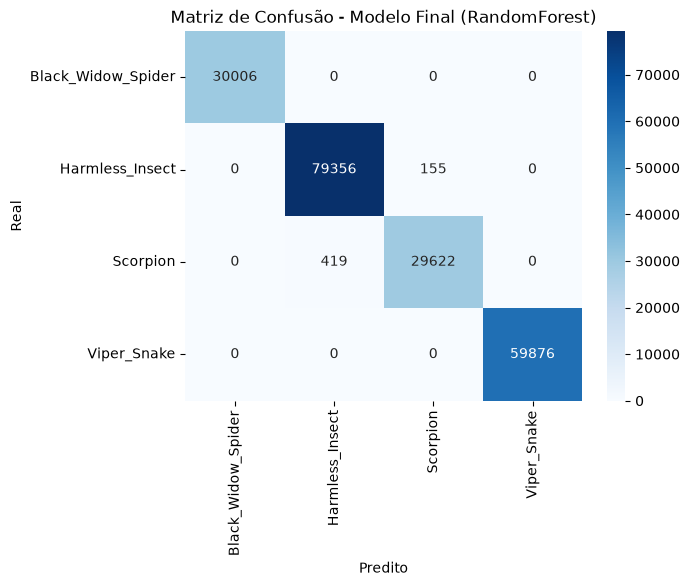

In [ ]:
cm_final = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Modelo Final (RandomForest)')
plt.show()

A diagonal principal mostra os casos onde o que o modelo previou bateu com o diagnóstico real. Houveram apenas 419 casos onde o modelo previous Harmless_Insect, mas era na verdade Scorpion, e 155 casos onde o modelo previu Scorpion, mas era na verdade Harmless_Insect.

### 7.3 Limitações

O dataset escolhido é artificial, gerado para fins didáticos, e possui algumas características que afetam a avaliação de modelos treinados nele, como:

- Existência de atributos com relação determinística com o alvo: `Local_Swelling` identifica sozinho, com 100% de certeza e zero exceções nos dados, duas das quatro classes (`None` → sempre `Black_Widow_Spider`, 150.157 casos; `Medium`/`Severe` → sempre `Viper_Snake`, 299.928 casos). `Muscle_Paralysis_Present` e `Blood_Coagulation_Failure` reforçam esse padrão de forma unidirecional. Em pacientes reais, sintomas costumam se sobrepor entre diagnósticos diferentes, o que dificilmente geraria uma separação tão limpa.

- Ausência de ruído de medição, comorbidades e casos atípicos: os sinais vitais (`Heart_Rate_BPM`, `Blood_Pressure_Systolic`) seguem distribuições bem comportadas por classe, sem a variabilidade que doenças pré-existentes, erros de aferição ou exceções clínicas introduziriam em um cenário real de pronto-socorro.

- Desempenho quase perfeito (acurácia ~99,7%) é, portanto, reflexo da estrutura determinística dos dados sintéticos, e não uma evidência de que o modelo generalizaria igualmente bem para o diagnóstico real de picadas/mordidas em pacientes.

### 7.4 Possíveis melhorias

- **Ajuste de hiperparâmetros**: os parâmetros usados no RandomForest (`n_estimators=200`, `max_depth=None`, etc.) foram fixados por valores comuns, sem uma busca sistemática. Técnicas como `GridSearchCV` ou `RandomizedSearchCV`, otimizando pelo F1-macro, poderiam melhorar ainda mais o desempenho, especialmente na fronteira entre `Harmless_Insect` e `Scorpion`, onde está concentrado todo o erro do modelo.

- **Validação com dados reais**: como o dataset é sintético e parcialmente determinístico, o desempenho aqui reportado não pode ser extrapolado diretamente para uso clínico. Poderia validar o modelo em uma base de dados real de pacientes.